In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [3]:
train_path = "Downloads/train.csv"
test_path = "Downloads/test.csv"

df = pd.read_csv(train_path)
dft = pd.read_csv(test_path)

print("Train shape:", df.shape)
print("Test shape:", dft.shape)
df.head()


Train shape: (5, 12)
Test shape: (5, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NaN,S


In [4]:
def extract_title(name: str) -> str:
    if pd.isna(name):
        return ""
    raw = name.split(",")[1].split(".")[0].strip()
    title_map = {
        "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
        "Lady": "Royal", "Countess": "Royal", "Sir": "Royal",
        "Don": "Royal", "Dona": "Royal", "Jonkheer": "Royal",
        "Capt": "Officer", "Col": "Officer", "Major": "Officer",
        "Dr": "Officer", "Rev": "Officer"
    }
    return title_map.get(raw, raw)

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    d["Title"] = d["Name"].apply(extract_title)
    d["FamilySize"] = d["SibSp"].fillna(0) + d["Parch"].fillna(0) + 1
    d["IsAlone"] = (d["FamilySize"] == 1).astype(int)
    d["TicketGroup"] = d.groupby("Ticket")["Ticket"].transform("count")
    d["HasCabin"] = (~d["Cabin"].isna()).astype(int)
    return d

df = engineer_features(df)
dft = engineer_features(dft)


In [7]:
def build_model(random_state=42):
    numeric_features = ["Age", "Fare", "FamilySize", "TicketGroup"]
    categorical_features = ["Pclass", "Sex", "Embarked", "Title", "HasCabin", "IsAlone"]

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", num_pipe, numeric_features),
        ("cat", cat_pipe, categorical_features)
    ])

    lr = LogisticRegression(max_iter=300)
    rf = RandomForestClassifier(random_state=random_state)

    pipe = Pipeline([("pre", preprocessor), ("clf", rf)])

    param_grid = [
        {"clf": [lr], "clf__C": [0.2, 1.0, 3.0]},
        {"clf": [rf], "clf__n_estimators": [200, 400],
         "clf__max_depth": [None, 6, 10]}
    ]

    search = GridSearchCV(
        pipe, param_grid,
        scoring="roc_auc",
        cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=random_state),
        n_jobs=-1, verbose=1
    )
    return search


Fitting 2 folds for each of 9 candidates, totalling 18 fits
Best Params: {'clf': LogisticRegression(max_iter=300), 'clf__C': 0.2}
Best CV ROC AUC: 0.5

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       2.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0

ROC AUC: 0.0


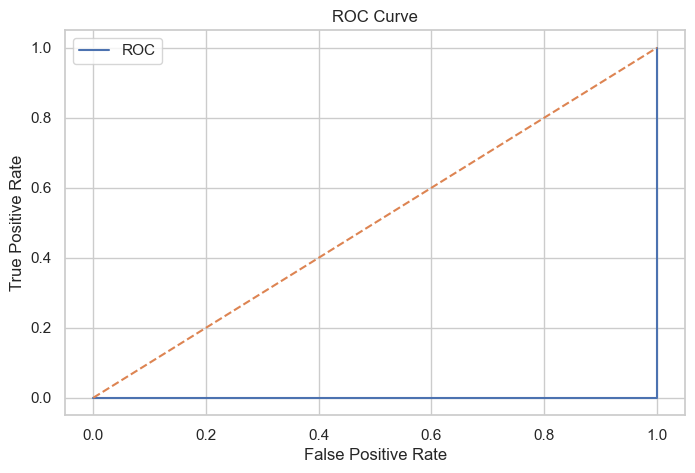

['titanic_best_model.joblib']

In [9]:
X = df.drop(columns=["Survived", "PassengerId", "Name", "Ticket", "Cabin"])
y = df["Survived"]

model_search = build_model()
model_search.fit(X, y)

print("Best Params:", model_search.best_params_)
print("Best CV ROC AUC:", model_search.best_score_)

# Holdout validation
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.5, random_state=42)
best_model = model_search.best_estimator_
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_val)
y_prob = best_model.predict_proba(X_val)[:,1]

print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("ROC AUC:", roc_auc_score(y_val, y_prob))

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_val, y_prob)
plt.plot(fpr, tpr, label="ROC")
plt.plot([0,1],[0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Save model
joblib.dump(best_model, "titanic_best_model.joblib")


In [10]:
Xt = dft.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])
preds = best_model.predict(Xt)

submission = pd.DataFrame({
    "PassengerId": dft["PassengerId"],
    "Survived": preds
})
submission.to_csv("submission.csv", index=False)
print("✔ Submission saved to submission.csv")
submission.head()


✔ Submission saved to submission.csv


,PassengerId,Survived
0,892,1
1,893,1
2,894,0
3,895,0
4,896,0
